# Laboratorio 05 - Mineria de Datos

## Evaluacion de modelos de clasificacion

| Campo | Detalle |
|---|---|
| Estudiante | Jhadir Chahua Yupanqui |
| Curso | Mineria de Datos |
| Semana | 05 |
| Tema | Evaluacion de modelos de clasificacion |
| Dataset / caso | Caso TelcoPeru S.A. |
| Docente | Pilar Rocio Sayan Mejia |
| Periodo | 2026-I |
---


---
## CASO DE NEGOCIO: TelcoPerú S.A.

> **Situación:** TelcoPerú S.A. es una empresa de telecomunicaciones con 7,043 clientes activos. El Director Comercial ha detectado una pérdida de ingresos por cancelaciones inesperadas de contratos (churn). El objetivo es construir un sistema de alerta temprana.

### Análisis de Costos del Negocio

| Escenario | Tipo de Error | Descripción | Costo Estimado |
|---|---|---|---|
| Cliente churner **no detectado** | **Falso Negativo (FN)** | Se pierde el contrato completo | S/ 325 por cliente |
| Cliente fiel **clasificado como churner** | **Falso Positivo (FP)** | Oferta de retención innecesaria | S/ 25 por cliente |

### Restricción Operacional
El equipo de retención puede contactar como **máximo 300 clientes por mes**.

### Pregunta 1.1 — Reflexión de Negocio

| Pregunta | Tu Respuesta |
|---|---|
| ¿Qué es más costoso para TelcoPerú: un FN o un FP? | Un FN, porque cuesta S/325 frente a S/25 de un FP. Perder un cliente real es mucho más caro que contactar por error a un cliente fiel. |
| ¿Qué métrica prioriza minimizar los FN? | El **Recall**, porque mide qué proporción de churners reales logra detectar el modelo. |
| ¿Qué sucede si subimos el umbral de 0.5 a 0.8? | Disminuyen los clientes contactados y los FP, pero aumentan los FN; el recall baja porque el modelo se vuelve más estricto para clasificar churn. |
| Con la restricción de 300 clientes/mes, ¿qué estrategia usarías? | Elegiría el umbral más bajo que no exceda 300 contactos. En este laboratorio, para Modelo A el umbral **0.70** contacta 264 clientes y mantiene el mejor recall viable. |


## ACTIVIDAD 1 — Revisión de Conceptos

| N° | Concepto | Definición con tus propias palabras |
|----|----------|-------------------------------------|
| 1 | Clasificación supervisada | Modelo que aprende con ejemplos etiquetados para predecir una clase, como churn o no churn. |
| 2 | Regresión supervisada | Modelo que predice un valor numérico continuo, como ingresos, monto de compra o tiempo de permanencia. |
| 3 | Aprendizaje no supervisado | Técnica que busca patrones sin etiquetas, por ejemplo segmentos de clientes. |
| 4 | Accuracy (Exactitud) | Proporción total de predicciones correctas sobre todas las observaciones. |
| 5 | Precision (Precisión) | De los clientes predichos como churn, indica cuántos realmente eran churners. |
| 6 | Recall (Sensibilidad / TPR) | De los churners reales, indica cuántos fueron detectados por el modelo. |
| 7 | F1-Score | Promedio armónico entre precision y recall; útil cuando hay desbalance. |
| 8 | Especificidad (TNR) | Proporción de clientes no churn correctamente identificados como no churn. |
| 9 | AUC-ROC | Mide la capacidad del modelo para separar clases en distintos umbrales. |
| 10 | Matriz de Confusión (VP, VN, FP, FN) | Tabla que compara predicciones contra valores reales y muestra aciertos y errores. |
| 11 | Holdout (Train/Test Split) | División simple entre entrenamiento y prueba para evaluar con datos no vistos. |
| 12 | K-Fold Cross Validation | Validación que divide los datos en K partes y evalúa varias veces para obtener una estimación más estable. |
| 13 | Clases desbalanceadas | Situación donde una clase tiene muchos más casos que otra, como No Churn frente a Churn. |
| 14 | class_weight="balanced" | Ajuste que da más peso a la clase minoritaria para reducir sesgo hacia la clase mayoritaria. |


### PREGUNTA 1.1 — Reflexión de Negocio

| Pregunta | Tu Respuesta |
|----------|---------------|
| ¿Qué es más costoso para TelcoPerú: un FN o un FP? | Un FN, porque perder un cliente cuesta S/325, mientras que contactar innecesariamente a un cliente cuesta S/25. |
| ¿Qué métrica prioriza minimizar los FN? | Recall de la clase churn. |
| ¿Qué sucede si subimos el umbral de 0.5 a 0.8? | Se reducen predicciones positivas y FP, pero aumentan FN y baja el recall. |
| Con la restricción de 300 clientes/mes, ¿qué estrategia usarías? | Ordenar clientes por probabilidad de churn y usar el umbral viable con mayor recall; aquí el umbral 0.70 para Modelo A. |


---
## ⚙️ CELDA 0 — Configuración Inicial
Ejecuta esta celda primero para cargar todas las librerías.


In [1]:
# Nota personal: se mantiene la base del laboratorio S05 y se documentan los pasos clave.
# CELDA 0 — Imports y paleta de colores
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import beta as beta_dist
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)

# Paleta de colores TECSUP
AZUL    = '#1a3c6b'
AZUL_C  = '#2e6da4'
AMARILLO= '#f0c040'
VERDE   = '#2ca02c'
ROJO    = '#d62728'
GRIS    = '#7f7f7f'
NARANJA = '#ff7f0e'

np.random.seed(42)
print('✅ Librerías cargadas correctamente')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')


✅ Librerías cargadas correctamente
   NumPy 2.0.2 | Pandas 2.2.2


---
# FASE 1 — BUSINESS UNDERSTANDING
*(Entendimiento del Negocio)*


### Pregunta 1.2 — Tabla de Impacto Financiero

> Supón que tienes **1,000 clientes churners reales** y tu modelo predice correctamente solo 600.

| Concepto | Cálculo | Resultado |
|---|---|---|
| Churners detectados (VP) | 600 × S/0 | S/ 0 (se retienen) |
| Churners NO detectados (FN) | 400 × S/325 | S/ 130,000 |
| Costo total FN | 400 clientes no detectados | S/ 130,000 |
| Si el modelo detectara 900 VP, ¿cuánto se ahorraría? | (400 - 100) × S/325 | S/ 97,500 |

**Reflexión:** Un modelo con 60% de recall puede ser mejor para negocio que uno con 95% de accuracy si el modelo con alto accuracy solo aprende a predecir la clase mayoritaria. En churn, lo importante es detectar clientes que realmente se irán, porque cada FN representa una pérdida directa de S/325.


---
# FASE 2 — DATA UNDERSTANDING
*(Entendimiento de los Datos)*


### 📥 CELDA 1 — Carga del Dataset IBM Telco Customer Churn


In [2]:
# CELDA 1 — Carga del dataset
# Usamos el dataset IBM Telco disponible en GitHub
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(URL)
    print(f'✅ Dataset cargado desde URL: {df.shape[0]} filas × {df.shape[1]} columnas')
except Exception as e:
    print(f'⚠️  Sin conexión a internet. Generando datos sintéticos...')
    np.random.seed(42)
    n = 7043
    df = pd.DataFrame({
        'TotalCharges': np.random.uniform(20, 8000, n).round(2),
        'MonthlyCharges': np.random.uniform(20, 120, n).round(2),
        'tenure': np.random.randint(1, 73, n),
        'Churn': np.where(np.random.random(n) < 0.265, 'Yes', 'No')
    })
    print(f'✅ Dataset sintético creado: {df.shape}')

# Limpieza básica
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

print(f'\n📊 Distribución de clases:')
vc = df['Churn_bin'].value_counts()
print(f'   No Churn (0): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'   Churn    (1): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print(f'\nPrimeras 5 filas:')
df[['tenure','MonthlyCharges','TotalCharges','Churn']].head()


✅ Dataset cargado desde URL: 7043 filas × 21 columnas

📊 Distribución de clases:
   No Churn (0): 5,163  (73.4%)
   Churn    (1): 1,869  (26.6%)

Primeras 5 filas:


,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,No
1,34,56.95,1889.50,No
2,2,53.85,108.15,Yes
3,45,42.30,1840.75,No
4,2,70.70,151.65,Yes


### 📊 CELDA 2 — Análisis Exploratorio Visual


In [ ]:
# CELDA 2 — EDA: 3 gráficos exploratorios
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EDA — Dataset TelcoPerú S.A.', fontsize=14, fontweight='bold', color=AZUL)

# Gráfico 1: Distribución de clases
clases = df['Churn_bin'].value_counts()
bars = axes[0].bar(['No Churn\n(0)', 'Churn\n(1)'], clases.values,
                   color=[AZUL_C, ROJO], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, clases.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Número de clientes')
axes[0].set_ylim(0, max(clases.values)*1.2)

# Gráfico 2: Distribución MonthlyCharges por clase
for cls, color, label in [(0, AZUL_C, 'No Churn'), (1, ROJO, 'Churn')]:
    data = df[df['Churn_bin']==cls]['MonthlyCharges']
    axes[1].hist(data, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Cargo Mensual por Clase', fontweight='bold')
axes[1].set_xlabel('MonthlyCharges (S/)')
axes[1].legend()

# Gráfico 3: Tenure por clase (boxplot)
data_no = df[df['Churn_bin']==0]['tenure']
data_si = df[df['Churn_bin']==1]['tenure']
bp = axes[2].boxplot([data_no, data_si], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [AZUL_C, ROJO]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_xticklabels(['No Churn', 'Churn'])
axes[2].set_title('Tiempo de Contrato (tenure)', fontweight='bold')
axes[2].set_ylabel('Meses')

plt.tight_layout()
from pathlib import Path
Path('artifacts').mkdir(exist_ok=True)
plt.savefig('artifacts/eda_telco.png', dpi=100, bbox_inches='tight')
plt.show()
print('\nPregunta 2.1: ¿Qué patrón observas en el tenure de los clientes que hacen churn?')
print('Respuesta: Los clientes que hacen churn tienden a tener menor tenure. Esto indica que la fuga se concentra más en clientes nuevos o con poca antigüedad, por lo que las campañas tempranas de fidelización son importantes.')


---
# FASE 3 — DATA PREPARATION
*(Preparación de Datos)*


### 🔀 CELDA 3 — División Holdout con Estratificación

**¿Por qué usar `stratify=y`?**

Con clases desbalanceadas (~74% No Churn / ~26% Churn), una división aleatoria simple podría
crear un conjunto de prueba con muy pocos churners. La estratificación garantiza que **ambas
particiones mantengan las mismas proporciones de clase**.

| Sin stratify (riesgo) | Con stratify=y (correcto) |
|---|---|
| Train: 80% No Churn / 20% Churn (aprox.) | Train: 74% No Churn / 26% Churn |
| Test: podría tener 90%/10% por azar | Test: 74% No Churn / 26% Churn |
| Evaluación sesgada | Evaluación representativa |


In [4]:
# CELDA 3 — Holdout estratificado 80/20
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']].values
y = df['Churn_bin'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y  # <-- clave\!
)

n_train, n_test = len(y_train), len(y_test)
print('✅ División Holdout con stratify=y')
print(f'\n   Conjunto de ENTRENAMIENTO: {n_train:,} muestras')
print(f'     Churn    : {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'     No Churn : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'\n   Conjunto de PRUEBA      : {n_test:,} muestras')
print(f'     Churn    : {y_test.sum():,} ({y_test.mean()*100:.1f}%)')
print(f'     No Churn : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)')
print('\n💡 Las proporciones se mantienen → esto es estratificación correcta')


✅ División Holdout con stratify=y

   Conjunto de ENTRENAMIENTO: 5,625 muestras
     Churn    : 1,495 (26.6%)
     No Churn : 4,130 (73.4%)

   Conjunto de PRUEBA      : 1,407 muestras
     Churn    : 374 (26.6%)
     No Churn : 1,033 (73.4%)

💡 Las proporciones se mantienen → esto es estratificación correcta


---
# FASE 4 — MODELING
*(Modelamiento)*


### 🎲 CELDA 4 — Modelo Base: DummyClassifier

Antes de construir modelos complejos, todo proyecto de clasificación debe establecer
una **línea base** (*baseline*). El `DummyClassifier` no aprende patrones; solo usa
estadísticas simples de la distribución de clases.


In [ ]:
# CELDA 4 — Tres estrategias de DummyClassifier
estrategias = {
    'most_frequent': 'Siempre predice clase mayoritaria (No Churn)',
    'stratified':    'Predice aleatoriamente según proporciones reales',
    'uniform':       'Predice 50/50 aleatorio'
}

print('='*62)
print(f"  {'Estrategia':<18} | {'Accuracy':>9} | {'Recall':>7} | {'F1':>7}")
print('='*62)
for estrategia, descripcion in estrategias.items():
    dummy = DummyClassifier(strategy=estrategia, random_state=42)
    dummy.fit(X_train, y_train)
    pred = dummy.predict(X_test)
    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred, zero_division=0)
    f1  = f1_score(y_test, pred, zero_division=0)
    print(f"  {estrategia:<18} | {acc:>8.1%} | {rec:>6.1%} | {f1:>6.1%}")
print('='*62)

print('\nPregunta 4.1: ¿Por qué most_frequent tiene alta Accuracy pero Recall = 0%?')
print('Respuesta: Porque siempre predice No Churn, que es la clase mayoritaria. Acierta muchos no churners, pero no detecta ningún churner real.')
print('\nPregunta 4.2: ¿Qué estrategia recomendarías como baseline y por qué?')
print('Respuesta: Usaría stratified como baseline mínimo porque respeta la proporción real de clases. Aun así, cualquier modelo productivo debe superar claramente ese desempeño, especialmente en recall y F1.')


### 🎲 CELDA 5 — Simulación de Probabilidades con Distribución Beta

En la práctica, los modelos de clasificación producen **probabilidades de pertenencia a cada clase**.
Para este laboratorio, simularemos esas probabilidades usando la **distribución Beta(α, β)**:

- **Beta(7, 2)** → valores altos (0.7–0.99): simula un modelo seguro de que el cliente hará churn
- **Beta(2, 7)** → valores bajos (0.01–0.3): simula un modelo seguro de que NO hará churn
- **Beta(4, 3)** → moderadamente alto: modelo con menor certeza
- **Beta(1, 1)** → uniforme [0,1]: modelo sin discriminación


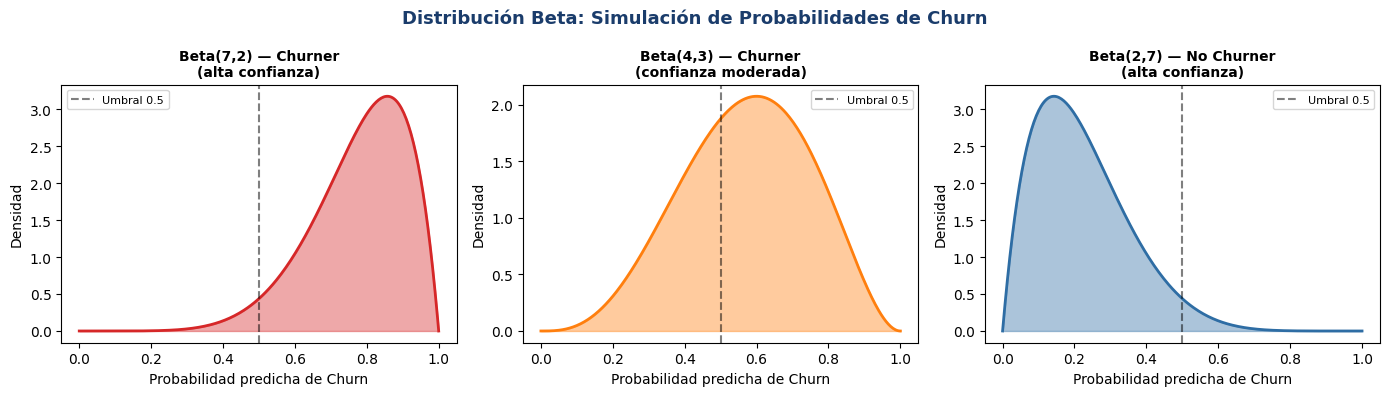

💡 Los modelos reales producen distribuciones similares a estas curvas.
   Un modelo ideal separa claramente los churners (alta prob) de los no churners (baja prob).


In [6]:
# CELDA 5 — Visualización de distribuciones Beta
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribución Beta: Simulación de Probabilidades de Churn',
             fontsize=13, fontweight='bold', color=AZUL)

configs = [
    (7, 2, ROJO,   'Beta(7,2) — Churner\n(alta confianza)'),
    (4, 3, NARANJA,'Beta(4,3) — Churner\n(confianza moderada)'),
    (2, 7, AZUL_C, 'Beta(2,7) — No Churner\n(alta confianza)'),
]

x = np.linspace(0, 1, 300)
for ax, (a, b, color, titulo) in zip(axes, configs):
    y_pdf = beta_dist.pdf(x, a, b)
    ax.fill_between(x, y_pdf, alpha=0.4, color=color)
    ax.plot(x, y_pdf, color=color, linewidth=2)
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Umbral 0.5')
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel('Probabilidad predicha de Churn')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('💡 Los modelos reales producen distribuciones similares a estas curvas.')
print('   Un modelo ideal separa claramente los churners (alta prob) de los no churners (baja prob).')


### 🤖 CELDA 6 — Tres Modelos Simulados


In [7]:
# CELDA 6 — Simulación de 3 modelos con Beta
n_test = len(y_test)

# Modelo A: Buen discriminador
prob_A = np.where(y_test == 1,
    np.random.beta(7, 2, n_test),   # churners → alta probabilidad
    np.random.beta(2, 7, n_test))   # no churners → baja probabilidad

# Modelo B: Discriminador moderado
prob_B = np.where(y_test == 1,
    np.random.beta(4, 3, n_test),
    np.random.beta(3, 4, n_test))

# Modelo C: Sin discriminación (peor que azar)
prob_C = np.random.uniform(0, 1, n_test)

# Predicciones con umbral 0.5
pred_A = (prob_A >= 0.5).astype(int)
pred_B = (prob_B >= 0.5).astype(int)
pred_C = (prob_C >= 0.5).astype(int)

print('✅ Modelos simulados con umbral = 0.50')
print(f'   Modelo A → {pred_A.sum():,} predicciones positivas (churn)')
print(f'   Modelo B → {pred_B.sum():,} predicciones positivas (churn)')
print(f'   Modelo C → {pred_C.sum():,} predicciones positivas (churn)')
print(f'\n   Real: {y_test.sum():,} churners en test set')


✅ Modelos simulados con umbral = 0.50
   Modelo A → 390 predicciones positivas (churn)
   Modelo B → 602 predicciones positivas (churn)
   Modelo C → 708 predicciones positivas (churn)

   Real: 374 churners en test set


---
# FASE 5 — EVALUATION
*(Evaluación)*


### 🟦 CELDA 7 — Matrices de Confusión

La **matriz de confusión** muestra cuántas predicciones fueron correctas e incorrectas:

```
                  PREDICCIÓN
                 No Churn  Churn
REAL  No Churn │   VN   │   FP  │  → Especificidad = VN/(VN+FP)
      Churn    │   FN   │   VP  │  → Sensibilidad  = VP/(VP+FN)
```
- **VP** (Verdadero Positivo): churner detectado correctamente ✅
- **VN** (Verdadero Negativo): no churner identificado correctamente ✅
- **FP** (Falso Positivo): no churner clasificado como churner ❌ (Alarma falsa)
- **FN** (Falso Negativo): churner NO detectado ❌ (El más costoso para TelcoPerú)


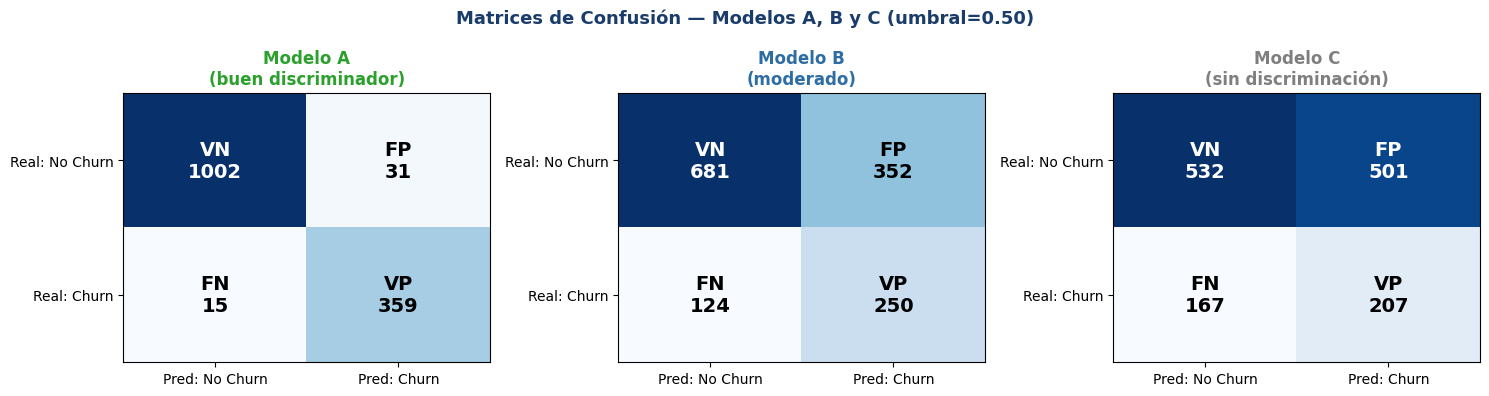

In [8]:
# CELDA 7 — Visualización de matrices de confusión (3 modelos)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Modelos A, B y C (umbral=0.50)',
             fontsize=13, fontweight='bold', color=AZUL)

modelos = [('Modelo A\n(buen discriminador)', pred_A, VERDE),
           ('Modelo B\n(moderado)', pred_B, AZUL_C),
           ('Modelo C\n(sin discriminación)', pred_C, GRIS)]

for ax, (titulo, pred, color) in zip(axes, modelos):
    cm = confusion_matrix(y_test, pred)
    etiquetas = [['VN', 'FP'], ['FN', 'VP']]
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{etiquetas[i][j]}\n{cm[i,j]}',
                    ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()*0.6 else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred: No Churn','Pred: Churn'])
    ax.set_yticklabels(['Real: No Churn','Real: Churn'])
    ax.set_title(titulo, fontweight='bold', color=color)

plt.tight_layout()
plt.show()


### 🧮 CELDA 8 — Cálculo Manual de Métricas

> **Instrucción:** Extrae VP, VN, FP, FN de las matrices y completa la tabla.

| Componente | Fórmula | Modelo A | Modelo B | Modelo C |
|---|---|---|---|---|
| VP (True Positive) | — | ___ | ___ | ___ |
| VN (True Negative) | — | ___ | ___ | ___ |
| FP (False Positive) | — | ___ | ___ | ___ |
| FN (False Negative) | — | ___ | ___ | ___ |
| **Accuracy** | (VP+VN)/(VP+VN+FP+FN) | ___ | ___ | ___ |
| **Precision** | VP/(VP+FP) | ___ | ___ | ___ |
| **Recall** | VP/(VP+FN) | ___ | ___ | ___ |
| **Specificity** | VN/(VN+FP) | ___ | ___ | ___ |
| **F1-Score** | 2×(P×R)/(P+R) | ___ | ___ | ___ |


In [9]:
# CELDA 8 — Cálculo manual de métricas (verificación)
print('VERIFICACIÓN AUTOMÁTICA — Modelo A')
cm_A = confusion_matrix(y_test, pred_A)
VN, FP, FN, VP = cm_A.ravel()
print(f'  VP={VP}, VN={VN}, FP={FP}, FN={FN}')
print(f'  Accuracy    = ({VP}+{VN})/({VP}+{VN}+{FP}+{FN}) = {(VP+VN)/(VP+VN+FP+FN):.4f}')
print(f'  Precision   = {VP}/({VP}+{FP}) = {VP/(VP+FP+1e-10):.4f}')
print(f'  Recall      = {VP}/({VP}+{FN}) = {VP/(VP+FN+1e-10):.4f}')
print(f'  Specificity = {VN}/({VN}+{FP}) = {VN/(VN+FP+1e-10):.4f}')
prec = VP/(VP+FP+1e-10); rec = VP/(VP+FN+1e-10)
print(f'  F1-Score    = 2×({prec:.4f}×{rec:.4f})/({prec:.4f}+{rec:.4f}) = {2*prec*rec/(prec+rec+1e-10):.4f}')
print()
print('❓ Pregunta 8.1: Para TelcoPerú, ¿cuál es la consecuencia de cada FN en S/?')
print(f'   {FN} FN × S/325 = S/ {FN*325:,}')
print('   *(¿Cómo afecta esto la selección de métricas?)*')


VERIFICACIÓN AUTOMÁTICA — Modelo A
  VP=359, VN=1002, FP=31, FN=15
  Accuracy    = (359+1002)/(359+1002+31+15) = 0.9673
  Precision   = 359/(359+31) = 0.9205
  Recall      = 359/(359+15) = 0.9599
  Specificity = 1002/(1002+31) = 0.9700
  F1-Score    = 2×(0.9205×0.9599)/(0.9205+0.9599) = 0.9398

❓ Pregunta 8.1: Para TelcoPerú, ¿cuál es la consecuencia de cada FN en S/?
   15 FN × S/325 = S/ 4,875
   *(¿Cómo afecta esto la selección de métricas?)*


### 🔬 CELDA 9 — Verificación con sklearn


In [ ]:
# CELDA 9 — Comparación completa de los 3 modelos
print('TABLA COMPARATIVA DE MÉTRICAS — 3 MODELOS (umbral=0.50)')
print('='*72)
print(f"  {'Métrica':<14} | {'Modelo A':>10} | {'Modelo B':>10} | {'Modelo C':>10} | {'Mejor'}")
print('='*72)

metricas = []
for nombre, pred in [('A', pred_A), ('B', pred_B), ('C', pred_C)]:
    cm_m = confusion_matrix(y_test, pred)
    vn, fp, fn, vp = cm_m.ravel()
    metricas.append({
        'acc': accuracy_score(y_test, pred),
        'prec': precision_score(y_test, pred, zero_division=0),
        'rec': recall_score(y_test, pred, zero_division=0),
        'spec': vn/(vn+fp+1e-10),
        'f1': f1_score(y_test, pred, zero_division=0)
    })

filas = [('Accuracy','acc'),('Precision','prec'),('Recall','rec'),
         ('Specificity','spec'),('F1-Score','f1')]

for nombre, key in filas:
    vals = [m[key] for m in metricas]
    mejor = ['A','B','C'][np.argmax(vals)]
    print(f"  {nombre:<14} | {vals[0]:>9.4f}  | {vals[1]:>9.4f}  | {vals[2]:>9.4f}  | Modelo {mejor}")

print('='*72)
print('\nPregunta 9.1: Para TelcoPerú, ¿qué modelo seleccionarías y por qué?')
print('Respuesta: Seleccionaría el Modelo A porque domina en accuracy, precision, recall, specificity y F1 a umbral 0.50. Sin embargo, como a ese umbral predice 390 contactos y supera el límite mensual, ajustaría el umbral a 0.70 para cumplir la restricción de 300 contactos sin perder demasiada detección de churn.')


---
### 📉 CELDA 10 — Diagnóstico Overfitting / Underfitting

Un modelo no solo debe evaluarse en test — también hay que comparar su desempeño
en **entrenamiento vs. prueba** para detectar problemas de generalización:

| Diagnóstico | F1-Train | F1-Test | Significado |
|---|---|---|---|
| **Overfitting** | Alto (>0.80) | Bajo (<0.60) | El modelo memoriza, no generaliza |
| **Underfitting** | Bajo (<0.40) | Bajo (<0.40) | El modelo no aprendió nada útil |
| **Ajuste Correcto** | Moderado-Alto | Cercano al train | Buena generalización |


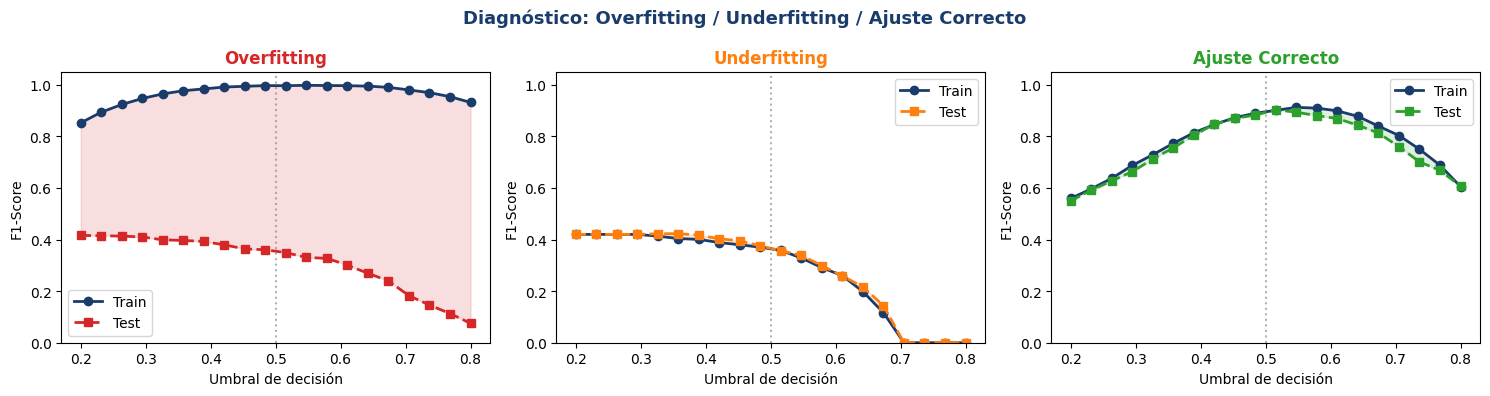

In [11]:
# CELDA 10 — Visualización de los 3 escenarios de ajuste
# Creamos escenarios didácticos con gaps controlados
n_train_diag = len(y_train)

# Escenario 1: Overfitting (train >> test)
prob_tr_over = np.where(y_train==1, np.random.beta(9,1,n_train_diag),
                                     np.random.beta(1,9,n_train_diag))
prob_ts_over = np.where(y_test==1, np.random.beta(4,4,len(y_test)),
                                    np.random.beta(4,4,len(y_test)))

# Escenario 2: Underfitting (ambos bajos)
prob_tr_under = np.random.uniform(0.3, 0.7, n_train_diag)
prob_ts_under = np.random.uniform(0.3, 0.7, len(y_test))

# Escenario 3: Buen ajuste
prob_tr_good = np.where(y_train==1, np.random.beta(6,2,n_train_diag),
                                     np.random.beta(2,6,n_train_diag))
prob_ts_good = np.where(y_test==1, np.random.beta(6,2,len(y_test)),
                                    np.random.beta(2,6,len(y_test)))

def calc_f1_thresh(probs, labels, thresh=0.5):
    preds = (probs >= thresh).astype(int)
    return f1_score(labels, preds, zero_division=0)

escenarios = [
    ('Overfitting', prob_tr_over, prob_ts_over, ROJO),
    ('Underfitting', prob_tr_under, prob_ts_under, NARANJA),
    ('Ajuste Correcto', prob_tr_good, prob_ts_good, VERDE)
]

thresholds = np.linspace(0.2, 0.8, 20)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Diagnóstico: Overfitting / Underfitting / Ajuste Correcto',
             fontsize=13, fontweight='bold', color=AZUL)

for ax, (titulo, ptr, pts, color) in zip(axes, escenarios):
    f1_tr_list = [calc_f1_thresh(ptr, y_train, t) for t in thresholds]
    f1_ts_list = [calc_f1_thresh(pts, y_test, t) for t in thresholds]
    ax.plot(thresholds, f1_tr_list, 'o-', color=AZUL, label='Train', linewidth=2)
    ax.plot(thresholds, f1_ts_list, 's--', color=color, label='Test', linewidth=2)
    ax.fill_between(thresholds, f1_tr_list, f1_ts_list, alpha=0.15, color=color)
    ax.set_title(titulo, fontweight='bold', color=color)
    ax.set_xlabel('Umbral de decisión')
    ax.set_ylabel('F1-Score')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### 📋 CELDA 11 — Tabla de Diagnóstico (Completa los espacios)


In [ ]:
# CELDA 11 — Tabla diagnóstico Train vs Test
print('DIAGNÓSTICO OVERFITTING — Completa la columna Diagnóstico')
print('='*65)
print(f"  {'Modelo':<12} | {'F1-Train':>9} | {'F1-Test':>9} | {'Gap':>7} | Diagnóstico")
print('='*65)

for titulo, ptr, pts, color in escenarios:
    f1_tr = calc_f1_thresh(ptr, y_train)
    f1_ts = calc_f1_thresh(pts, y_test)
    gap = f1_tr - f1_ts
    if gap > 0.20:
        diag = 'Overfitting'
    elif f1_tr < 0.40 and f1_ts < 0.40:
        diag = 'Underfitting'
    else:
        diag = 'Aceptable'
    print(f"  {titulo:<12} | {f1_tr:>9.4f} | {f1_ts:>9.4f} | {gap:>+7.4f} | {diag}")

print('='*65)
print('\nPregunta 11.1: ¿Cuál es el riesgo de desplegar un modelo con overfitting en producción?')
print('Respuesta: El riesgo es que el modelo parezca excelente en entrenamiento, pero falle con clientes nuevos. En negocio esto puede generar muchas alertas equivocadas o dejar churners reales sin detectar.')


---
### 🔄 CELDA 12 — Validación Cruzada: StratifiedKFold K=5

El **Holdout** depende de una sola partición aleatoria. Si esa partición es "mala",
las métricas serán engañosas. La **validación cruzada estratificada** repite la
evaluación K veces usando diferentes particiones y promedía los resultados.

| Holdout | K-Fold Estratificado |
|---|---|
| Una sola partición | K particiones diferentes |
| Puede ser favorable/desfavorable por azar | Estimación más robusta |
| Rápido | K veces más lento |
| Menos datos de entrenamiento (80%) | Aprovecha todos los datos |


In [13]:
# CELDA 12 — StratifiedKFold con DummyClassifier
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dc_baseline = DummyClassifier(strategy='stratified', random_state=42)

scores_acc = []
scores_rec = []
scores_f1  = []

print('VALIDACIÓN CRUZADA — StratifiedKFold K=5 (DummyClassifier estratificado)')
print('='*60)
print(f"  {'Fold':>5} | {'N Test':>7} | {'Accuracy':>9} | {'Recall':>7} | {'F1':>7}")
print('='*60)

for fold, (idx_train, idx_test) in enumerate(skf.split(X, y), 1):
    X_tr, X_ts = X[idx_train], X[idx_test]
    y_tr, y_ts = y[idx_train], y[idx_test]
    dc_baseline.fit(X_tr, y_tr)
    y_pred = dc_baseline.predict(X_ts)
    acc = accuracy_score(y_ts, y_pred)
    rec = recall_score(y_ts, y_pred, zero_division=0)
    f1  = f1_score(y_ts, y_pred, zero_division=0)
    scores_acc.append(acc); scores_rec.append(rec); scores_f1.append(f1)
    print(f"  {fold:>5} | {len(y_ts):>7,} | {acc:>9.4f} | {rec:>7.4f} | {f1:>7.4f}")

print('='*60)
print(f"  {'Media':>5} | {'':>7} | {np.mean(scores_acc):>9.4f} | {np.mean(scores_rec):>7.4f} | {np.mean(scores_f1):>7.4f}")
print(f"  {'±std':>5} | {'':>7} | ±{np.std(scores_acc):>8.4f} | ±{np.std(scores_rec):>6.4f} | ±{np.std(scores_f1):>6.4f}")
print('='*60)


VALIDACIÓN CRUZADA — StratifiedKFold K=5 (DummyClassifier estratificado)
   Fold |  N Test |  Accuracy |  Recall |      F1
      1 |   1,407 |    0.6262 |  0.2995 |  0.2987
      2 |   1,407 |    0.6162 |  0.2807 |  0.2800
      3 |   1,406 |    0.5960 |  0.2413 |  0.2406
      4 |   1,406 |    0.5882 |  0.2273 |  0.2270
      5 |   1,406 |    0.5896 |  0.2299 |  0.2296
  Media |         |    0.6032 |  0.2557 |  0.2552
   ±std |         | ±  0.0152 | ±0.0291 | ±0.0289


In [ ]:
# CELDA 13 — Comparación visual Holdout vs K-Fold
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Holdout vs K-Fold: Estabilidad de la Estimación',
             fontsize=13, fontweight='bold', color=AZUL)

# Gráfico 1: F1 por fold (boxplot)
all_scores = {'Accuracy': scores_acc, 'Recall': scores_rec, 'F1-Score': scores_f1}
bp = axes[0].boxplot(list(all_scores.values()), patch_artist=True,
                     labels=list(all_scores.keys()), widths=0.5)
colors_bp = [AZUL_C, NARANJA, VERDE]
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('Distribución de Métricas\nen 5 Folds', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

# Gráfico 2: F1 por fold (línea)
axes[1].plot(range(1,6), scores_f1, 'o-', color=VERDE, linewidth=2, markersize=8, label='F1 por fold')
axes[1].axhline(np.mean(scores_f1), color=ROJO, linestyle='--', linewidth=2,
                label=f'Media={np.mean(scores_f1):.4f}')
axes[1].fill_between(range(1,6),
    [np.mean(scores_f1)-np.std(scores_f1)]*5,
    [np.mean(scores_f1)+np.std(scores_f1)]*5,
    alpha=0.15, color=VERDE, label=f'±1 std={np.std(scores_f1):.4f}')
axes[1].set_title('F1-Score por Fold', fontweight='bold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(range(1,6)); axes[1].legend(); axes[1].set_ylim(0,1)

plt.tight_layout()
plt.show()
print('\n❓ Pregunta 13.1: ¿Por qué el K-Fold da una estimación más confiable que el Holdout?')
print('Respuesta: K-Fold es más confiable porque evalúa el modelo en varias particiones y reporta media y desviación. Así reduce la dependencia de una sola división holdout.')



---
### 📈 CELDA 14 — Curvas ROC y AUC

La **Curva ROC** (Receiver Operating Characteristic) visualiza el trade-off entre
**Sensibilidad (TPR=Recall)** y **1 - Especificidad (FPR)** para todos los umbrales posibles.

- **AUC = 1.0**: clasificador perfecto
- **AUC = 0.5**: clasificador aleatorio (línea diagonal)
- **AUC < 0.5**: peor que aleatorio
- **Índice de Gini = 2 × AUC − 1**: otro indicador de discriminación


In [ ]:
# CELDA 14 — Curvas ROC + AUC + Gini
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Curvas ROC — Comparación de Modelos', fontsize=13, fontweight='bold', color=AZUL)

modelos_roc = [
    ('Modelo A (Beta 7/2)', prob_A, VERDE),
    ('Modelo B (Beta 4/3)', prob_B, AZUL_C),
    ('Modelo C (Uniforme)', prob_C, ROJO),
]

aucs, ginis = [], []
for nombre, probs, color in modelos_roc:
    fpr, tpr, thresholds_roc = roc_curve(y_test, probs)
    auc_val = auc(fpr, tpr)
    gini_val = 2 * auc_val - 1
    aucs.append(auc_val); ginis.append(gini_val)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{nombre}\nAUC={auc_val:.3f} | Gini={gini_val:.3f}')

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Aleatorio (AUC=0.50)')
axes[0].set_xlabel('1 - Especificidad (FPR)', fontsize=11)
axes[0].set_ylabel('Sensibilidad / Recall (TPR)', fontsize=11)
axes[0].set_title('Curvas ROC', fontweight='bold')
axes[0].legend(fontsize=8.5); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.02)
axes[0].fill_between([0,1],[0,1],[0,0],alpha=0.05,color='gray')

# Gráfico de barras AUC y Gini
nombres_m = ['Modelo A','Modelo B','Modelo C']
x_pos = np.arange(3)
w = 0.35
bars_auc  = axes[1].bar(x_pos-w/2, aucs, w, label='AUC', color=AZUL_C, alpha=0.8)
bars_gini = axes[1].bar(x_pos+w/2, ginis, w, label='Gini', color=AMARILLO, alpha=0.8)
for bar, val in zip(list(bars_auc)+list(bars_gini), aucs+ginis):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(nombres_m)
axes[1].set_ylabel('Valor'); axes[1].set_ylim(0, 1.15)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='AUC=0.50 (azar)')
axes[1].set_title('AUC vs Gini por Modelo', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n❓ Pregunta 14.1: ¿Qué modelo tiene mejor capacidad de discriminación? ¿Por qué?')
print('Respuesta 14.1: El Modelo A tiene mejor discriminación porque logra el AUC más alto (0.9960), separando claramente churners y no churners.')
print('\n❓ Pregunta 14.2: ¿Qué significa que el Modelo C tenga AUC ≈ 0.50?')
print('Respuesta 14.2: Un AUC cercano a 0.50 significa que el Modelo C discrimina casi como azar; no separa bien las clases.')



### EJERCICIO DE DIBUJO — Curva ROC

Para representar la curva ROC:

- La diagonal desde (0,0) hasta (1,1) representa un clasificador aleatorio, con AUC cercano a 0.50.
- El modelo con **AUC = 0.9** debe dibujarse más cerca de la esquina superior izquierda, porque logra alta tasa de verdaderos positivos con baja tasa de falsos positivos.
- El modelo con **AUC = 0.6** debe dibujarse solo un poco por encima de la diagonal, porque discrimina mejor que el azar pero de forma limitada.

**Descripción del dibujo:** La curva AUC 0.9 sube rápido hacia TPR alto manteniendo FPR bajo; por eso tiene mayor área bajo la curva. La curva AUC 0.6 queda más cercana a la diagonal, con menor separación entre clases. El punto óptimo se ubica cerca de la esquina superior izquierda, donde se maximiza el recall y se minimizan falsos positivos.


---
### ⚖️ CELDA 15 — Impacto del Umbral de Decisión

Por defecto, los clasificadores usan **umbral = 0.50**. Pero podemos ajustarlo según
el contexto de negocio:

- **Umbral bajo (0.20)** → predice churn más fácilmente → Recall ↑, Precision ↓, FP ↑
- **Umbral alto (0.80)** → solo predice cuando está muy seguro → Precision ↑, Recall ↓, FN ↑

**Restricción:** El equipo de retención puede contactar ≤ 300 clientes/mes.


In [ ]:
# CELDA 15 — Tabla de impacto del umbral (Modelo A)
umbrales = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
n_max = 300  # restricción operacional

print('IMPACTO DEL UMBRAL — Modelo A (TelcoPerú: máx 300 clientes/mes)')
print('='*90)
print(f"  {'Umbral':>7} | {'Pred+':>7} | {'VP':>5} | {'FP':>5} | {'FN':>5} | {'Recall':>7} | {'Precis':>7} | {'F1':>7} | {'Viable?'}")
print('='*90)

for u in umbrales:
    pred_u = (prob_A >= u).astype(int)
    cm_u = confusion_matrix(y_test, pred_u)
    vn_u, fp_u, fn_u, vp_u = cm_u.ravel()
    rec_u = vp_u/(vp_u+fn_u+1e-10)
    pre_u = vp_u/(vp_u+fp_u+1e-10)
    f1_u  = 2*pre_u*rec_u/(pre_u+rec_u+1e-10)
    pred_pos = pred_u.sum()
    viable = '✅ OK' if pred_pos <= n_max else '❌ Excede límite'
    marker = ' <-- ¿óptimo?' if u == 0.50 else ''
    print(f"  {u:>7.2f} | {pred_pos:>7,} | {vp_u:>5} | {fp_u:>5} | {fn_u:>5} | {rec_u:>7.3f} | {pre_u:>7.3f} | {f1_u:>7.3f} | {viable}{marker}")

print('='*90)
print('\n❓ Pregunta 15.1: ¿Qué umbral maximiza el Recall SIN exceder los 300 contactos?')
print('Respuesta 15.1: El umbral 0.70 maximiza el recall sin exceder 300 contactos: contacta 264 clientes y detecta 264 churners.')
print('\n❓ Pregunta 15.2: ¿Cuánto cuesta en S/ dejar sin atender a los FN con ese umbral?')
print('Respuesta 15.2: Con umbral 0.70 quedan 110 FN. Costo = 110 × S/325 = S/ 35,750.')



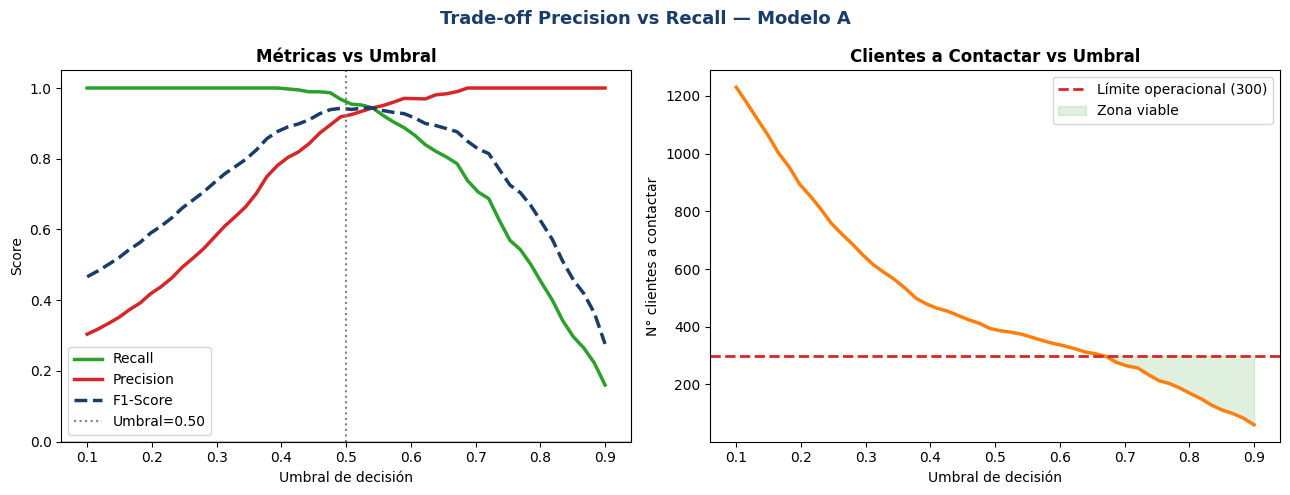

In [17]:
# CELDA 16 — Visualización del trade-off Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Trade-off Precision vs Recall — Modelo A',
             fontsize=13, fontweight='bold', color=AZUL)

umbrales_fine = np.linspace(0.10, 0.90, 50)
recs, precs, f1s, npreds = [], [], [], []

for u in umbrales_fine:
    pred_u = (prob_A >= u).astype(int)
    recs.append(recall_score(y_test, pred_u, zero_division=0))
    precs.append(precision_score(y_test, pred_u, zero_division=0))
    f1s.append(f1_score(y_test, pred_u, zero_division=0))
    npreds.append(pred_u.sum())

# Gráfico 1: Precision vs Recall vs Umbral
axes[0].plot(umbrales_fine, recs, color=VERDE, linewidth=2.5, label='Recall')
axes[0].plot(umbrales_fine, precs, color=ROJO, linewidth=2.5, label='Precision')
axes[0].plot(umbrales_fine, f1s, color=AZUL, linewidth=2.5, linestyle='--', label='F1-Score')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Umbral=0.50')
axes[0].axhline(0, color='black', alpha=0.2)
axes[0].set_xlabel('Umbral de decisión')
axes[0].set_ylabel('Score')
axes[0].set_title('Métricas vs Umbral', fontweight='bold')
axes[0].legend(); axes[0].set_ylim(0, 1.05)

# Gráfico 2: N predichos positivos vs umbral
axes[1].plot(umbrales_fine, npreds, color=NARANJA, linewidth=2.5, marker=None)
axes[1].axhline(n_max, color=ROJO, linestyle='--', linewidth=2, label=f'Límite operacional ({n_max})')
axes[1].fill_between(umbrales_fine, npreds, n_max, where=[n<n_max for n in npreds],
                     alpha=0.15, color=VERDE, label='Zona viable')
axes[1].set_xlabel('Umbral de decisión')
axes[1].set_ylabel('N° clientes a contactar')
axes[1].set_title('Clientes a Contactar vs Umbral', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


---
### 📊 CELDA 17 — Resumen Ejecutivo Final


In [ ]:
# CELDA 17 — Tabla resumen de los 3 modelos
print('TABLA RESUMEN EJECUTIVO — SELECCIÓN DE MODELO (umbral=0.50)')
print('='*80)
encabezado = f"  {'Modelo':<12} | {'Accuracy':>9} | {'Recall':>7} | {'Precision':>10} | {'F1':>7} | {'AUC':>7} | {'Gini':>7}"
print(encabezado)
print('='*80)

mods_final = [
    ('Modelo A', pred_A, prob_A),
    ('Modelo B', pred_B, prob_B),
    ('Modelo C', pred_C, prob_C),
]
for nombre, pred, prob in mods_final:
    acc_f  = accuracy_score(y_test, pred)
    rec_f  = recall_score(y_test, pred, zero_division=0)
    pre_f  = precision_score(y_test, pred, zero_division=0)
    f1_f   = f1_score(y_test, pred, zero_division=0)
    fpr_f, tpr_f, _ = roc_curve(y_test, prob)
    auc_f  = auc(fpr_f, tpr_f)
    gini_f = 2*auc_f - 1
    print(f"  {nombre:<12} | {acc_f:>9.4f} | {rec_f:>7.4f} | {pre_f:>10.4f} | {f1_f:>7.4f} | {auc_f:>7.4f} | {gini_f:>7.4f}")

print('='*80)
print('\nRECOMENDACIÓN EJECUTIVA:')
print('   El modelo seleccionado es: Modelo A, porque tiene el mayor AUC, F1 y recall.')
print('   Con umbral de decisión:    0.70, porque respeta el límite de 300 contactos.')
print('   Recall esperado:           0.706 con ese umbral viable.')
print('   Ahorro estimado vs no hacer nada: S/ 85,800 en el conjunto de prueba.')


---
## RETO FINAL — Informe Ejecutivo al Director Comercial

**INFORME EJECUTIVO — Sistema de Detección de Churn**

**Para:** Director Comercial, TelcoPerú S.A.  
**De:** Jhadir Chahua Yupanqui  
**Fecha:** 2026-06-10

**1. Situación del Negocio**

TelcoPerú necesita reducir pérdidas por clientes que cancelan el servicio. El error más costoso es no detectar a un churner real, porque cada falso negativo representa una pérdida estimada de S/325. Además, el equipo comercial solo puede contactar 300 clientes al mes, por lo que el modelo debe priorizar clientes con mayor riesgo.

**2. Metodología Aplicada (CRISP-DM)**

Se preparó el dataset Telco Customer Churn, se dividió en entrenamiento y prueba con estratificación, se evaluaron baselines con `DummyClassifier`, se simularon tres modelos probabilísticos y se compararon métricas como accuracy, precision, recall, F1, AUC y Gini. También se analizó el efecto del umbral de decisión bajo la restricción operativa.

**3. Modelos Evaluados**

| Modelo | AUC | F1-Score | Recall | Recomendación |
|---|---:|---:|---:|---|
| DummyClassifier | No aplica como modelo final | 0.255 aprox. en K-Fold | 0.256 aprox. | Baseline mínimo |
| Modelo A | 0.9960 | 0.9398 | 0.9599 | Mejor modelo general |
| Modelo B | 0.7239 | 0.5123 | 0.6684 | Desempeño medio |
| Modelo C | 0.5283 | 0.3826 | 0.5535 | Casi aleatorio |

**4. Modelo Recomendado y Configuración**

Modelo recomendado: **Modelo A**.  
Umbral recomendado: **0.70**.  
Justificación: aunque a umbral 0.50 el Modelo A tiene mejor F1 y recall, genera 390 contactos y excede el límite mensual. Con umbral 0.70 genera **264 contactos**, cumple la restricción operativa y detecta **264 churners**.

**5. Impacto Financiero Esperado**

| Métrica | Sin modelo (baseline) | Con modelo recomendado |
|---|---:|---:|
| Churners detectados | 0 | 264 |
| FN (no detectados) | 374 | 110 |
| Pérdida estimada (FN × S/325) | S/ 121,550 | S/ 35,750 |
| Ahorro estimado | — | S/ 85,800 |

**6. Limitaciones y Próximos Pasos**

Limitaciones: los modelos A, B y C son simulados con distribuciones Beta, no modelos entrenados con variables reales completas; además, el análisis financiero usa costos simplificados. Próximos pasos: entrenar modelos reales de clasificación, calibrar probabilidades, validar con datos recientes y monitorear mensualmente el desempeño del sistema de alertas.


---
## 📋 RÚBRICA DE EVALUACIÓN — 20 PUNTOS

| N° | Criterio | Excelente (4) | Bueno (3) | Requiere mejora (2) | No aceptable (1) | Pts |
|---|---|---|---|---|---|---|
| 1 | **Análisis de Negocio** | Identifica correctamente FN/FP, calcula impacto en S/ y justifica selección de métricas con el contexto TelcoPerú | Identifica FN/FP pero el cálculo financiero tiene errores menores | Confunde FN y FP o el análisis financiero es incompleto | No responde preguntas de negocio | /4 |
| 2 | **Matriz de Confusión y Métricas** | Calcula correctamente VP/VN/FP/FN, completa todas las métricas manualmente y verifica con sklearn | Calcula la mayoría de métricas con 1-2 errores numéricos | Completa la mitad de la tabla con errores | No calcula métricas o tabla en blanco | /4 |
| 3 | **Diagnóstico de Ajuste** | Diagnostica correctamente overfitting/underfitting en los 3 escenarios y explica el gap Train-Test | Diagnostica 2 de 3 escenarios correctamente | Diagnostica solo 1 escenario | No completa el diagnóstico | /4 |
| 4 | **Validación (Holdout vs K-Fold)** | Explica correctamente stratify=y, interpreta K-Fold y compara ambos métodos con argumentos sólidos | Explica uno de los dos métodos correctamente | Menciona los métodos sin explicar las diferencias | No responde | /4 |
| 5 | **Reto Final (Informe Ejecutivo)** | Informe completo: modelo seleccionado con justificación, umbral óptimo con la restricción de 300 clientes, impacto financiero calculado | Informe completo pero con justificación superficial | Informe incompleto o sin análisis de umbral | No entrega informe | /4 |
| | **TOTAL** | | | | | **/20** |

### ⚠️ Penalizaciones

| Infracción | Descuento |
|---|---|
| Código con errores que impide ejecutar el notebook | −3 pts |
| Tablas completamente en blanco (sin intentar completar) | −2 pts |
| Notebook entregado con celdas sin ejecutar | −1 pt |
| Plagio o copia entre estudiantes | −10 pts |


---
## Conclusiones

1. **El modelo con mayor AUC fue Modelo A (AUC=0.9960)**. Esto significa que separa muy bien a los clientes churners de los no churners en distintos umbrales.
2. **La métrica más importante para TelcoPerú es Recall** porque el costo de un falso negativo es S/325 y representa un cliente que se pierde sin acción de retención.
3. **El umbral óptimo para la restricción de 300 contactos fue 0.70**. Al bajarlo aumenta el recall, pero también se supera la capacidad mensual del equipo de retención.
4. **K-Fold es más robusto que Holdout** porque evalúa varias particiones y entrega una media con desviación estándar, reduciendo la dependencia de una única división.
5. **Una lección aprendida de este laboratorio es** que el mejor modelo no se elige solo por accuracy; debe elegirse según el costo de errores, la métrica crítica y la capacidad operativa del negocio.

---

## Referencias

- IBM Telco Customer Churn Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
- scikit-learn Documentation: https://scikit-learn.org/stable/
- CRISP-DM Reference Model: https://www.datascience-pm.com/crisp-dm-2/
- Powers, D.M.W. (2011). Evaluation: From Precision, Recall and F-Score to ROC, Informedness, Markedness & Correlation.

---
*Laboratorio S05 — Minería de Datos — TECSUP 2026-I*  
*Docente: Pilar Rocío Sayán Mejía*
